Antenne  0 :  [-0.14103932 -0.09450519]
Antenne  1 :  [ 0.16658811 -0.13354049]
Antenne  2 :  [0.06672257 0.13120369]
post =  [[array([-1.10604448,  1.064467  ,  0.        ,  0.        ])], [array([-0.56166529, -0.42060942,  0.        ,  1.        ])], [array([-0.24939825, -1.8247959 ,  0.        ,  2.        ])], [array([0.81617538, 0.23666564, 0.        , 3.        ])], [array([0.95592045, 1.1103567 , 0.        , 4.        ])], [array([-1.12452702, -1.58833179,  0.        ,  5.        ])], [array([1.96425054, 1.42069528, 0.        , 6.        ])], [array([ 1.7907224, -0.34526  ,  0.       ,  7.       ])], [array([-1.8511521 ,  0.26586328,  0.        ,  8.        ])], [array([-1.10919388,  0.55187769,  0.        ,  9.        ])], [array([-0.67038453,  1.21669122,  0.        , 10.        ])], [array([-1.09064033, -0.23220512,  0.        , 11.        ])], [array([ 1.56737853, -0.68755117,  0.        , 12.        ])], [array([-1.67649749,  0.89581517,  0.        , 13.        ])], [array(

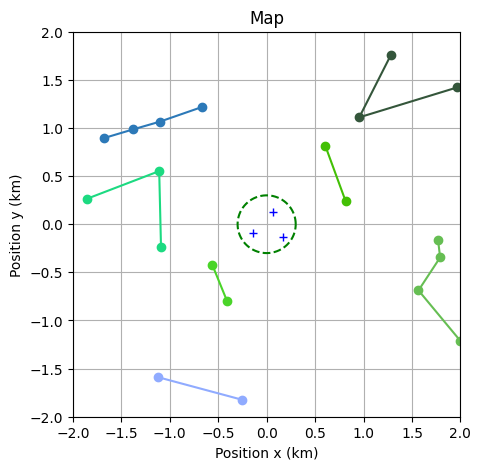

In [ ]:
import numpy as np
import random
from scipy.linalg import hilbert
import matplotlib.pyplot as plt

#Variables globales
landwidth = 2
rmaxdist = 0.2
tmindist = 0.3

Mt = 20
Mr = 3
v0 = 10
alpha = 3
kappa = 1
sigma = 10**(-2)
Pc = 0.01

#Définition fenêtre
fig, biax = plt.subplots()
fig.set_size_inches(5,5)
biax.set_xlabel("Position x (km)")
biax.set_ylabel("Position y (km)")
biax.set_xlim(-landwidth, landwidth)
biax.set_ylim(-landwidth, landwidth)

def CalcDistance(c1, c2):
    return np.sqrt((c2[0]-c1[0])**2 + (c2[1]-c1[1])**2)

def h_ij(c1, c2):
    return np.sqrt(kappa / CalcDistance(c1, c2)**alpha)

def Power_ij(c1, c2, dij):
    hij = np.sqrt(kappa / dij**alpha)
    return v0 * sigma**2 / hij**2

#--- La puissance qui reste à allouer à la connexion (le calcul se fait entre chaque i et î, l'utilisateur de S le plus loin de i)
def Power_S(s):
    if len(s) == 1:
        return Pc
    sum = 0
    for i in s:
        maxd = 0
        for j in s:
            temp = CalcDistance(i, j)
            if temp > maxd:
                maxd = temp
                imax = j
        #print("maxd = ", maxd, " et imax = ",imax)
        sum += Power_ij(i, imax, maxd)
        #print("sum = ",sum)
    return max(Pc - sum,0)

def SumDi(mu, lambda_is):
    sumDi = 0
    for lambda_i in lambda_is:
        if lambda_i > 0.001:
            sumDi += max(0, mu - 1/lambda_i)
    #print("sumDi = ",sumDi, " pour mu = ", mu)
    return sumDi

#--- Calcul de mu par force brute
def Calc_mu1(lambda_is, Ps): # Ce que j'ai tenté :
    # Initialisation
    mu = 0.1
    Di = SumDi(mu, lambda_is)
    cpt = 0
    while cpt < 5000: # éviter les boucles infinies (normalement pas nécessaire)
        # Ajout :
        if Di == 0:
            mu += 0.2
        elif (Di - Ps) > 0.001:
            mu -= 0.001
        elif (Di - Ps) < -0.001:
            mu += 0.001

        else:
            return mu
        cpt += 1
        Di = SumDi(mu, lambda_is)
    #print("-------")
    #print("ATTENTION")
    #print("CPT =", cpt)
    #print("-------")
    return mu

#--- Calcul de l'utilité (pour plus de détails, voir l'étude)
def v_s(post):
    #print("arg = ",post)
    Ps = Power_S(post)
    #print("Ps = ",Ps)
    if Ps <= 0:
        return 0

    n = Mr
    m = len(post)
    H = np.zeros((n,m)) #--- Matrice H
    for i in range(n):
        for j in range(m):
            H[i][j] = h_ij(listR[i],post[j])
    #print("H = ",H)
    Ht = np.transpose(H)
    #print("Ht = ",Ht)

    lambda_is = np.linalg.eig(np.dot(Ht,H))[0] #--- Valeurs propres de HtH (les lambda_i)
    for i in range(len(lambda_is)):
        lambda_is[i] = max(0, lambda_is[i])
    lambda_is.sort() #--- Un peu de clarté, ça peut pas faire de mal!
    #print("lambda_is = ",lambda_is)

    #mu = Calc_mu(lambda_is, Ps)
    mu = Calc_mu1(lambda_is, Ps)
    #print("mu = ",mu)

    Cs = 0
    for lambda_i in lambda_is:
        if lambda_i > 0.001: #--- On ne veut que les lambda strictement positifs
            #print(np.log10(mu*lambda_i))
            Cs += max(0,np.log10(mu*lambda_i))
    #print("Cs = ",Cs)

    return 100*m*Cs #--- On fait x100 pour plus de clarté, mais ça ne change rien aux comparaisons

def Linear_Tab(l):
    #print("on passe de ça : ",l)
    taille = len(l)
    i = 0
    while i < taille:
        if type(l[i][0]) is not np.float64:
            for elem in l[i]:
                l.append(elem)
            l.pop(i)
        else:
            i = i+1
    #print("à ça : ",l)
    return l

def powerset(s): #--- Trouvé sur le net puis adaptée
    x = len(s)
    res = []
    for i in range(1, 1 << x):
        res.append([s[j] for j in range(x) if (i & (1 << j))])
    return res[:-1]

def Merge(gliste):
    taille = len(gliste)
    i = 0
    reste = taille-1
    bestmerge = -1
    bestdist = 1000
    bestv = 0
    is_merge = 0
    while reste >= 1:
        temp1 = gliste[reste]
        temp2 = gliste[i]
        temp = Linear_Tab([gliste[reste], gliste[i]])
        #--- On compare le i-ème élément avec le reste-ième (de base, le dernier)
        v = v_s(temp)
        if v_s(temp1) + v_s(temp2) < v: #--- Condition du merge
            dist = CalcDistance(temp1[0], temp2[0])
            if dist < bestdist:
            #if v > bestv:
                bestmerge = i
                mer = temp
                bestdist = dist
                bestv = v
                #print("Pour ",temp1," : Le meilleur c'est ",temp2," (dist = ",CalcDistance(temp1[0], temp2[0])," et v = ",v,")")
        #--- On compare les 0<i<reste-1 éléments avec le reste-ième avant de décrémenter reste
        i = i+1
        if i >= reste:
            if bestmerge != -1:
                gliste.pop(reste)
                gliste.pop(bestmerge)
                gliste.append(mer)
                bestmerge = -1
                bestdist = 1000
                bestv = 0
                is_merge = 1
                #print(">>>>>>>>>>>>>>>>>>> MERGE")
            reste = reste - 1
            i = 0
        #print("----------------------------------------------")
        #print("i = ",i," et reste = ",reste)
        #print(gliste)
    #print("Merge : ",gliste)
    return gliste, is_merge


def Split(gliste):
    taille = len(gliste)
    s = 0
    is_split = 0
    while s < taille: #--- On traîte l'ensemble des subsets initiaux (ceux créés par le split sont ignorés)
        subset = gliste[s]
        #print("subset = ",subset)
        subt = len(subset)
        notsplit = True
        if subt > 1:
            pwrset = powerset(subset) #--- Fonction qui renvoie l'ensemble des sous-ensembles de subset (sauf le vide et lui-même)
            t = len(pwrset)
            i = 0
            while i < t//2 and notsplit:
                if v_s(pwrset[i]) + v_s(pwrset[t-i-1]) > v_s(subset): #--- Condition du split
                    #--- Il se trouve que pwrset[i] et pwrset[t-i-1] sont complémentaires (forment subset à eux deux mais n'ont aucun élément en commun)
                    gliste.pop(s)
                    gliste.append(pwrset[i])
                    gliste.append(pwrset[t-i-1])
                    #print(">>>>>>>>>>>>>>>>>>> SPLIT")
                    notsplit = False
                    taille = taille - 1 #--- On a enlevé un subset à traiter, donc on réduit la taille de 1
                    s = s - 1 #--- On contrebalance le +1 qui arrive (l'élément suivant obtient l'indice du précédent)
                    is_split = 1
                i = i+1
        s = s + 1 #--- On passe au subset suivant
    #print("Split : ",gliste)
    return gliste, is_split

#--- Appel de base, les calculs ne sont pas faits dans cette fonction
def Merge_Split(gliste):
    limit = 0
    while limit < 10: #--- Pour éviter les boucles infinies (on estime que la configuration finale est obtenue avant)
        #MERGE
        #print("###### Tour ",limit," ######")
        #print("-----Merge-----")
        gliste, mer = Merge(gliste)
        #SPLIT
        #print("-----Split-----")
        gliste, spl = Split(gliste)
        if mer + spl == 0: #--- Condition de terminaison de l'algorithme (stabilité)
            break
        limit = limit + 1
    return gliste

#--- Génération du terrain
def GenerateGrid():
    #--- Les antennes
    posr = [[0,0] for i in range(Mr)]
    for i in range(Mr):
        posr[i] = 2*rmaxdist* np.random.random_sample(2) - rmaxdist ## [-0.2, 0.2]
        print("Antenne ",i,": ",posr[i]) ## Des antennes pas à l'origine (à voir)

    #--- Les utilisateurs
    post = [[[0,0]] for i in range(Mt)]
    for i in range(Mt):
        #--- Répartition aléatoire...
        while post[i][0][0]**2 + post[i][0][1]**2 < tmindist**2: ## "around the BS" => donc en dehors du cercle : OK
            post[i] = [2*landwidth* np.random.random_sample(2) - landwidth]
            post[i][0] = np.append(post[i][0],[0])
            post[i][0] = np.append(post[i][0],[i])

    print("post = ",post)
    return posr, post


#--- Une fois les coalitions créées, on plot chaque point avec la couleur de leur coalition (aléatoire)
def plot_points(gliste, lr, r_color):
    angle = np.linspace( 0 , 2 * np.pi , 150 )
    plt.plot(tmindist * np.cos( angle ), tmindist * np.sin( angle ), '--', color = "green")
    for antenne in lr:
        plt.plot(antenne[0],antenne[1], color = "blue", marker = "+")
    for i in range(len(gliste)):
        ## Note : on peut donc avoir la même couleur pour 2 coalitions différentes
        plt.plot([j[0] for j in gliste[i]],[j[1] for j in gliste[i]], color = r_color[i], marker = "o")

def random_color_list():
    r_color = [tuple(np.random.random_sample(3)) for i in range(Mt)]
    return r_color

def utilite_finale(gliste, l_init):
    sum = 0
    for subset in gliste:
        sum += v_s(subset)
    sum_init = 0
    for pt in l_init:
        sum_init += v_s(pt)
    print("Utilité finale avec coalitions = ",sum," !")
    print("Utilité sans coalitions = ",sum_init," !")

#--- Déroulement du programme
listR, listT = GenerateGrid()
M_S = listT[:]
M_S = Merge_Split(M_S)
print("ET LE GRAND RESULTAT EST : ",M_S)
utilite_finale(M_S, listT)
r_color = random_color_list()
plot_points(M_S, listR, r_color)

plt.title("Map")
plt.grid(True)
plt.show()

Antenne  0 :  [-0.12571738 -0.15968331]
Antenne  1 :  [-0.11043435 -0.1118842 ]
Antenne  2 :  [-0.02723876  0.05623187]
post =  [[array([0.5521822 , 1.43566785, 0.        , 0.        ])], [array([-1.07148675,  0.42734206,  0.        ,  1.        ])], [array([ 0.12870611, -1.76814407,  0.        ,  2.        ])], [array([-1.58947761,  0.94158057,  0.        ,  3.        ])], [array([-1.73669781, -1.74290942,  0.        ,  4.        ])], [array([-0.3499115 , -1.80634522,  0.        ,  5.        ])], [array([ 1.88820705, -0.60155195,  0.        ,  6.        ])], [array([0.2830759 , 0.30421027, 0.        , 7.        ])], [array([-1.32871748,  1.00430076,  0.        ,  8.        ])], [array([-0.73076314, -1.99592782,  0.        ,  9.        ])], [array([-1.36596413,  1.91976942,  0.        , 10.        ])], [array([-0.74846079, -0.57696826,  0.        , 11.        ])], [array([ 0.26215706, -1.59768381,  0.        , 12.        ])], [array([-0.35330535, -0.07989392,  0.        , 13.        ])

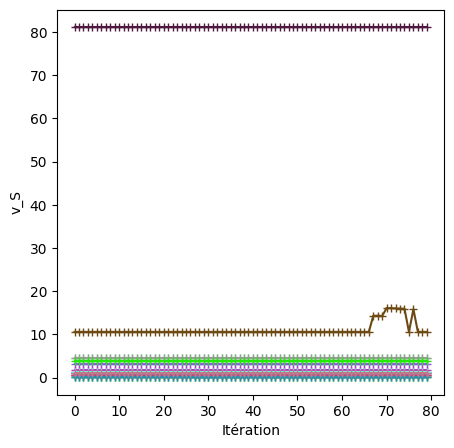

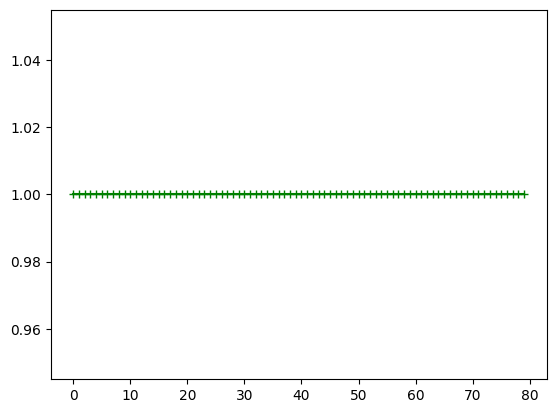

In [ ]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from operator import itemgetter

#Variables globales
landwidth = 2
rmaxdist = 0.2
tmindist = 0.3

Mt = 20
Mr = 3
v0 = 10
alpha = 3
kappa = 1
sigma = 10**(-2)
Pc = 0.01

nb_frames = 80

#Définition fenêtre
fig, biax = plt.subplots()
fig.set_size_inches(5,5)

def fair(s,v_coal, v_sum, v_indiv):
    #return (1/s)*(v_coal - v_sum) + v_indiv #Méthode 1
    return (v_indiv/v_sum)*(v_coal - v_sum) + v_indiv #Méthode 2

def Jain_index(coal):
    s = len(coal)
    sum1 = 0
    sum2 = 0
    for i in range(s):
        sum1 += coal[i][2]/v_s([coal[i]])
        sum2 += (coal[i][2]/v_s([coal[i]]))**2
    return sum1**2/(s*sum2)

def v_tab(gliste):
    Jain = []
    for coal in gliste:
        v_coal = v_s(coal)
        v_sum = [v_s([pt]) for pt in coal]
        v_sum = sum(v_sum)
        for i in range(len(coal)):
            coal[i][2] = fair(len(coal), v_coal, v_sum, v_s([coal[i]]))
        Jain.append(Jain_index(coal))
    Jain = np.mean(np.array(Jain))
    return gliste, Jain

def MS_update(frames):
    biax.clear()
    biax.set_xlabel("Position x (km)")
    biax.set_ylabel("Position y (km)")
    biax.set_xlim(-landwidth, landwidth)
    biax.set_ylim(-landwidth, landwidth)
    M_S = listT[:]
    M_S[0][0][0] += 0.05
    if M_S[0][0][0] > 2:
        M_S[0][0][0] = -landwidth
    M_S = Merge_Split(M_S)
    plot_points(M_S, listR, not_r_color)
    M_S, Jain = v_tab(M_S)
    v_list.append([pt[2] for pt in sorted(Linear_Tab(M_S), key=itemgetter(3))])
    Jain_list.append(Jain)
    biax.set(title=frames)
    plt.grid(True)
#--- Déroulement du programme
listR, listT = GenerateGrid()
r_color = random_color_list()
not_r_color = [(0,0.7,0) for i in listT] #Pour plus de lisibilité, on fixe la couleur pour l'animation

v_list = []
Jain_list = []

anim = animation.FuncAnimation(fig, MS_update, frames=nb_frames, interval=2, repeat=False)
anim.save("mobilite.gif", dpi=300, writer=PillowWriter(fps=8))

#--- Utilité
v_list = np.array(v_list)
biax.clear()
biax.set_xlabel("Itération")
biax.set_ylabel(r"v_S")
intervalle = np.arange(0, nb_frames)
for i in range(Mt):
    plt.plot(intervalle,v_list[1:,i], color = r_color[i], marker = "+")
plt.show()
biax.clear()

#--- Jain index
fig.set_size_inches(5,5)
biax.set_xlabel("Itération")
biax.set_ylabel(r"Jain index moyen")
intervalle = np.arange(0, nb_frames)
plt.plot(intervalle,Jain_list[1:], color = (0,0.5,0), marker = "+")
plt.show()
